## Assignment Task: Path Interpolation and Visualization

In this exercise, you are provided with a CSV file named `loop_track_waypoints.csv`, which contains a sequence of indexed 2D waypoints that form a closed-loop track. Your task is to interpolate these waypoints to generate a smooth continuous path and visualize the resulting curve.

### Dataset Description

The CSV file contains the following columns:

- `Index`: An integer representing the order of the waypoint.
- `x`: The x-coordinate of the waypoint (in meters).
- `y`: The y-coordinate of the waypoint (in meters).

The track is closed, i.e., the final waypoint coincides with the starting point to form a loop.

### Objectives

1. **Read** the CSV file using an appropriate data processing library such as `pandas`.
2. **Perform interpolation** over the waypoints using a method of your choice (e.g., `scipy.interpolate` or spline interpolation).
3. **Visualize** both the original discrete waypoints and the resulting smooth curve on the same plot for comparison.
4. Ensure the interpolated path **preserves the closed-loop nature** of the track.

### Recommended Libraries

You may use the following libraries:
- `pandas` for reading the CSV file.
- `matplotlib` or `plotly` for visualization.
- `scipy.interpolate` (e.g., `splprep` and `splev`) or `interp1d` for interpolation.

### 📌 Instructions

- Ensure that the file `loop_track_waypoints.csv` is placed in the **same directory** as this notebook.
- Label your axes and add a legend to your plot.
- Comment your code appropriately to explain the logic and steps used.
- Try using both linear and spline-based interpolation methods if time permits.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

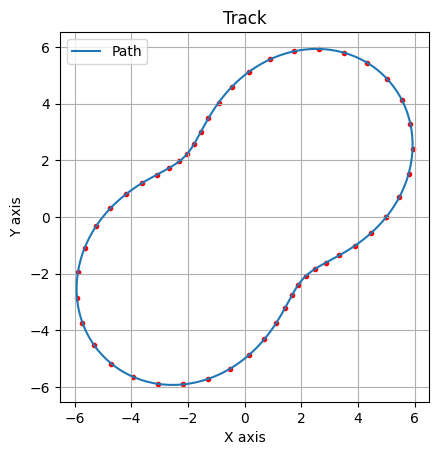

In [ ]:
data = pd.read_csv("loop_track_waypoints.csv")
points=data[["X","Y"]].to_numpy()
fig, ax = plt.subplots()
ax.set_aspect('equal')
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.title("Track")
plt.grid(True)
ax.scatter(points[:,0], points[:,1], marker='.',color='red')
tck, u = splprep([points[:,0], points[:,1]], s=0, per=True) 
# per = periodic closure ie continuity constraints
# s = smoothing factor so for s=0 curve passes through all points but if s> then best fit curve

v = np.linspace(0,1,1000) # 1000 u values btwn 0 n 1
x,y = splev(v, tck) # generates x(v) and y(v)
ax.plot(x,y,label="Path")
ax.legend()
plt.show()